In [18]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px

import warnings
warnings.filterwarnings("ignore")

In [33]:
orders = pd.read_csv("../data/processed/orders_clean.csv")

In [48]:
orders.head()
orders.shape
orders.columns
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       99441 non-null  object 
 1   customer_id                    99441 non-null  object 
 2   order_status                   99441 non-null  object 
 3   order_purchase_timestamp       99441 non-null  object 
 4   order_approved_at              99281 non-null  object 
 5   order_delivered_carrier_date   97658 non-null  object 
 6   order_delivered_customer_date  96476 non-null  object 
 7   order_estimated_delivery_date  99441 non-null  object 
 8   purchase_year                  99441 non-null  int64  
 9   purchase_month                 99441 non-null  int64  
 10  purchase_day                   99441 non-null  int64  
 11  purchase_weekday               99441 non-null  object 
 12  delivery_days                  96476 non-null 

In [61]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
purchase_year                       0
purchase_month                      0
purchase_day                        0
purchase_weekday                    0
delivery_days                    2965
dtype: int64

In [73]:
orders.duplicated().sum()

np.int64(0)

In [84]:
orders.describe()

,purchase_year,purchase_month,purchase_day,delivery_days
count,99441.000000,99441.000000,99441.000000,96476.000000
mean,2017.539838,6.032220,15.505948,12.094086
std,0.505007,3.232999,8.667298,9.551746
min,2016.000000,1.000000,1.000000,0.000000
25%,2017.000000,3.000000,8.000000,6.000000
50%,2018.000000,6.000000,15.000000,10.000000
75%,2018.000000,8.000000,23.000000,15.000000
max,2018.000000,12.000000,31.000000,209.000000


In [103]:
orders.describe(include="object")
orders.dtypes

order_id                          object
customer_id                       object
order_status                      object
order_purchase_timestamp          object
order_approved_at                 object
order_delivered_carrier_date      object
order_delivered_customer_date     object
order_estimated_delivery_date     object
purchase_year                      int64
purchase_month                     int64
purchase_day                       int64
purchase_weekday                  object
delivery_days                    float64
dtype: object

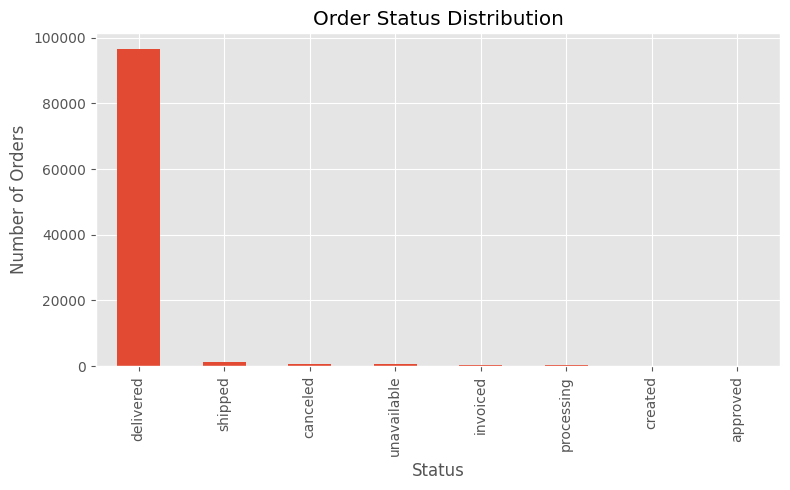

In [111]:
orders["order_status"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Order Status Distribution")
plt.xlabel("Status")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

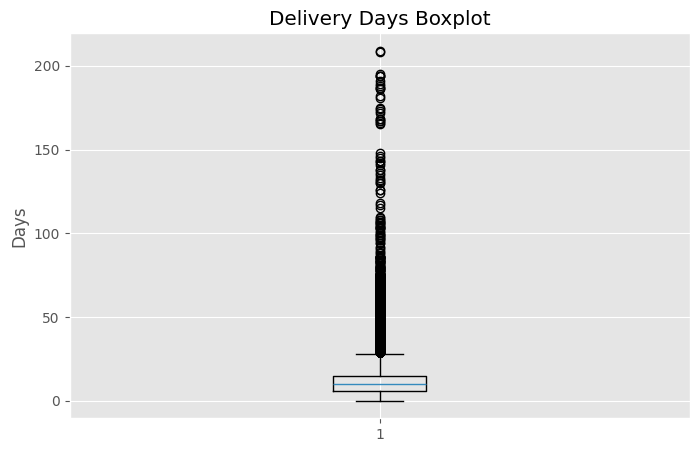

In [122]:
plt.figure(figsize=(8,5))

plt.boxplot(orders["delivery_days"].dropna())

plt.title("Delivery Days Boxplot")
plt.ylabel("Days")

plt.show()

Business Insight

• Most deliveries occur within the interquartile range.
• A few orders took significantly longer than average, indicating potential delivery delays.
• These outliers should be investigated to understand logistics issues.

FileNotFoundError: [Errno 2] No such file or directory: '../reports/figures/orders_by_month.png'

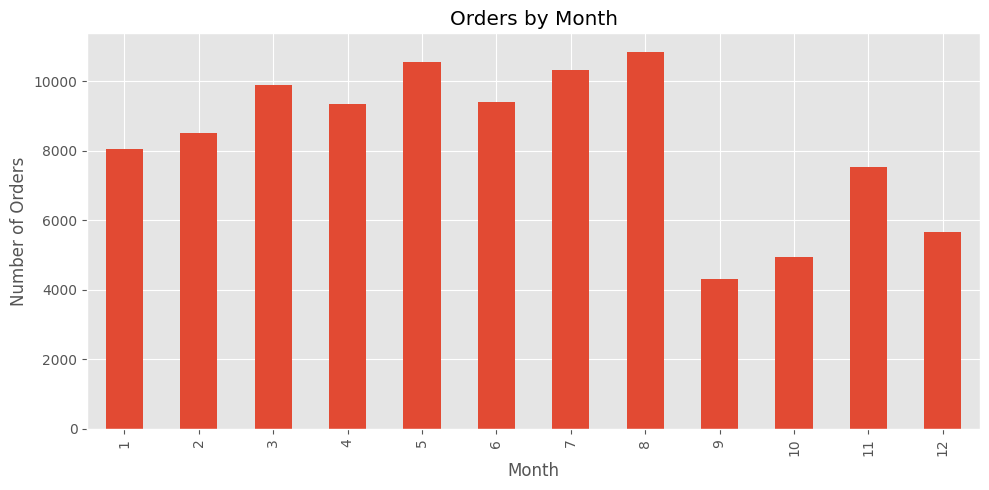

In [129]:
monthly_orders = (
    orders.groupby("purchase_month")
          .size()
          .sort_index()
)

plt.figure(figsize=(10,5))

monthly_orders.plot(kind="bar")

plt.title("Orders by Month")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.tight_layout()

plt.savefig("../reports/figures/orders_by_month.png")

plt.show()

Business Insight

• Order volume is highest during ______.
• The lowest number of orders occurs in ______.
• Seasonal trends may influence customer purchasing behavior.

FileNotFoundError: [Errno 2] No such file or directory: '../reports/figures/orders_by_weekday.png'

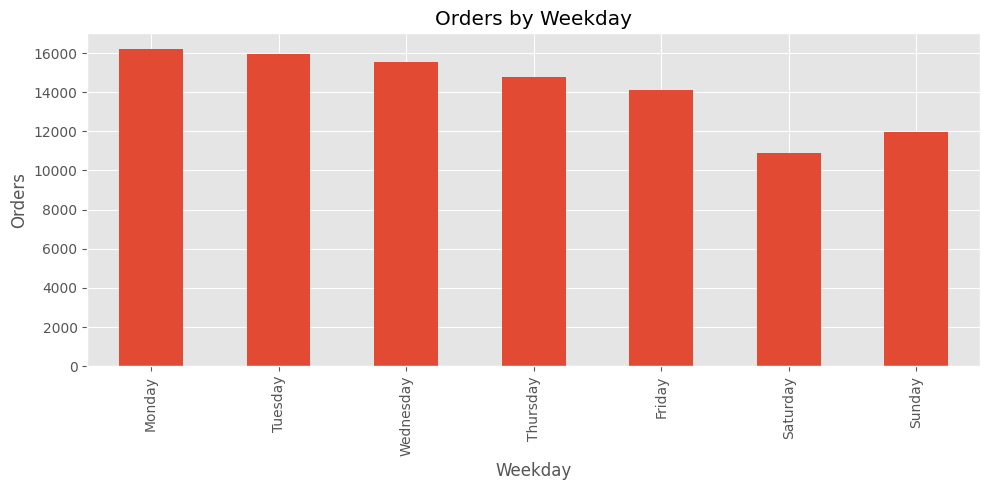

In [130]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_counts = (
    orders["purchase_weekday"]
    .value_counts()
    .reindex(weekday_order)
)

plt.figure(figsize=(10,5))

weekday_counts.plot(kind="bar")

plt.title("Orders by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Orders")

plt.tight_layout()

plt.savefig("../reports/figures/orders_by_weekday.png")

plt.show()

In [131]:
average_delivery = orders["delivery_days"].mean()

print(f"Average Delivery Time: {average_delivery:.2f} days")

print(f"Minimum Delivery Time: {orders['delivery_days'].min()} days")
print(f"Maximum Delivery Time: {orders['delivery_days'].max()} days")

Average Delivery Time: 12.09 days
Minimum Delivery Time: 0.0 days
Maximum Delivery Time: 209.0 days


FileNotFoundError: [Errno 2] No such file or directory: '../reports/figures/delivery_by_status.png'

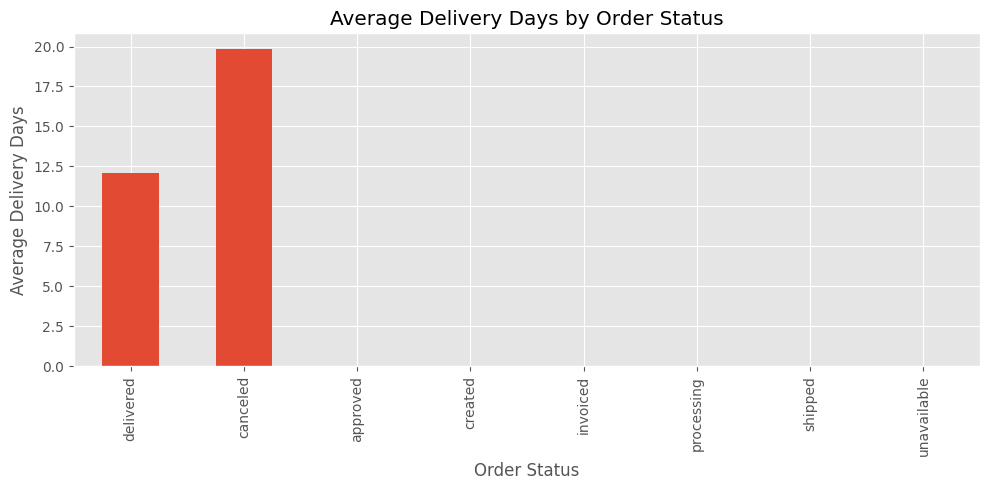

In [132]:
delivery_status = (
    orders.groupby("order_status")["delivery_days"]
          .mean()
          .sort_values()
)

plt.figure(figsize=(10,5))

delivery_status.plot(kind="bar")

plt.title("Average Delivery Days by Order Status")
plt.xlabel("Order Status")
plt.ylabel("Average Delivery Days")

plt.tight_layout()

plt.savefig("../reports/figures/delivery_by_status.png")

plt.show()

In [133]:
numeric_cols = orders.select_dtypes(include=["number"])

print(numeric_cols.corr())

                purchase_year  purchase_month  purchase_day  delivery_days
purchase_year        1.000000       -0.550059     -0.043672      -0.050156
purchase_month      -0.550059        1.000000      0.001343      -0.054398
purchase_day        -0.043672        0.001343      1.000000      -0.000528
delivery_days       -0.050156       -0.054398     -0.000528       1.000000


# Key Business Insights

1. Most orders are successfully delivered.
2. Order volume varies across months, indicating seasonal demand.
3. Certain weekdays experience higher order activity.
4. Average delivery time is approximately __ days.
5. A few orders have unusually long delivery times, suggesting potential logistics issues.
6. These insights can help improve inventory planning and delivery operations.